# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

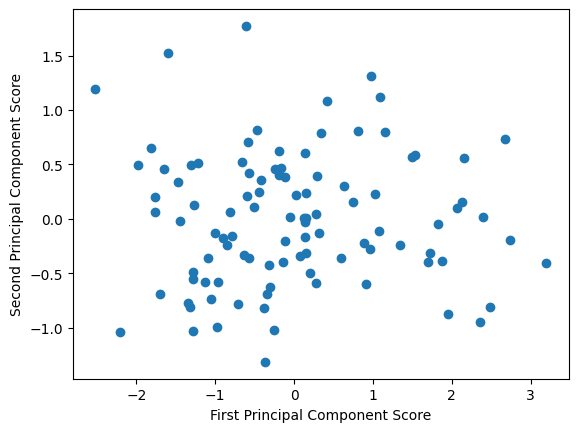

In [35]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

The three outliers in the upper left have low PC1 scores(around −2 to −2.5) and high PC2 scores(around +1.2 to +1.6).

Low PC1 basically means these observations are low overall across all three series, since PC1 usually captures the general "level" of the data. High PC2 means there's some contrast going on. Some variables are pulling differently than others for these points.

If series_3 has a strong loading on PC2, then these outliers probably have a relatively high series_3 value compared to what you'd expect given their low PC1. So series_3 is kind of the odd one out for these points; less suppressed than the other two, maybe even above average.

For series_1 and series_2 though, it's really hard to say anything, and nearly impossible to compare them to each other. That's probably because they were created to be highly correlated. Either one is derived from the other, or they share the same underlying signal. When two variables move together that closely, PCA just lumps them into PC1 and they basically cancel in PC2. So you can tell they're both low, but you can't tell which one is "more" low or what's different between them.

A pairplot would most likey show this clearly. Series_1 vs series_2 would be a tight diagonal line, while series_3 would look messier or different.

**Advantages of the plot:** it's a clean way to visualize three dimensions at once, and it makes those three outliers more obvious.

**Disadvantages:** the axes are abstract and hard to interpret without looking at the loadings, correlated variables become invisible to each other (exactly the series_1/series_2 problem), and you don't even know how much variance PC2 is explaining — if it's like 5%, the vertical axis is almost meaningless.

The plot is useful for spotting outliers, but it hides more than it shows without extra context.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

In [36]:
import kagglehub
import seaborn as sns
import matplotlib.pyplot as plt
import os
# Download latest version
path = kagglehub.dataset_download("ammaraahmad/us-ecommerce-record-2020")

ecom_data = pd.read_csv(os.path.join(path, os.listdir(path)[0]), encoding='latin1')
ecom_data.head()

,Order Date,Row ID,Order ID,Ship Mode,Customer ID,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,01-01-20,849,CA-2017-107503,Standard Class,GA-14725,Consumer,United States,Lorain,Ohio,44052,East,FUR-FU-10003878,Furniture,Furnishings,"Linden 10"" Round Wall Clock, Black",48.896,4,0.2,8.5568
1,01-01-20,4010,CA-2017-144463,Standard Class,SC-20725,Consumer,United States,Los Angeles,California,90036,West,FUR-FU-10001215,Furniture,Furnishings,"Howard Miller 11-1/2"" Diameter Brentwood Wall ...",474.430,11,0.0,199.2606
2,01-01-20,6683,CA-2017-154466,First Class,DP-13390,Home Office,United States,Franklin,Wisconsin,53132,Central,OFF-BI-10002012,Office Supplies,Binders,Wilson Jones Easy Flow II Sheet Lifters,3.600,2,0.0,1.7280
3,01-01-20,8070,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,454.560,5,0.2,-107.9580
4,01-01-20,8071,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,Central,FUR-FU-10002116,Furniture,Furnishings,"Tenex Carpeted, Granite-Look or Clear Contempo...",141.420,5,0.6,-187.3815


In [37]:
ecom_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3312 entries, 0 to 3311
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3312 non-null   object 
 1   Row ID        3312 non-null   int64  
 2   Order ID      3312 non-null   object 
 3   Ship Mode     3312 non-null   object 
 4   Customer ID   3312 non-null   object 
 5   Segment       3312 non-null   object 
 6   Country       3312 non-null   object 
 7   City          3312 non-null   object 
 8   State         3312 non-null   object 
 9   Postal Code   3312 non-null   int64  
 10  Region        3312 non-null   object 
 11  Product ID    3312 non-null   object 
 12  Category      3312 non-null   object 
 13  Sub-Category  3312 non-null   object 
 14  Product Name  3312 non-null   object 
 15  Sales         3312 non-null   float64
 16  Quantity      3312 non-null   int64  
 17  Discount      3312 non-null   float64
 18  Profit        3312 non-null 

In [38]:
# encode categoricals
ecom_data = pd.get_dummies(ecom_data, columns=['Segment', 'Region', 'Category', 'Ship Mode'], drop_first=True)

# update numeric dataframe
ecom_data_numeric = ecom_data.select_dtypes(include='number')

In [39]:
ecom_data_numeric.columns

Index(['Row ID', 'Postal Code', 'Sales', 'Quantity', 'Discount', 'Profit'], dtype='object')

In [40]:
ecom_data_numeric.info()
ecom_data_numeric.drop(columns=['Row ID'], inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3312 entries, 0 to 3311
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Row ID       3312 non-null   int64  
 1   Postal Code  3312 non-null   int64  
 2   Sales        3312 non-null   float64
 3   Quantity     3312 non-null   int64  
 4   Discount     3312 non-null   float64
 5   Profit       3312 non-null   float64
dtypes: float64(3), int64(3)
memory usage: 155.4 KB


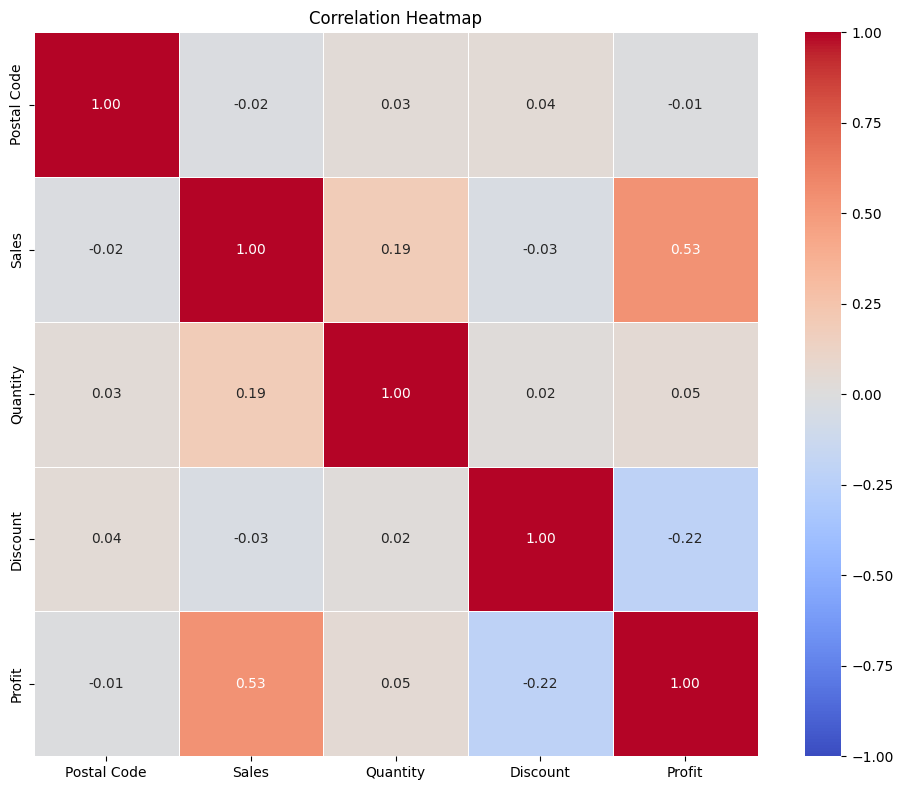

In [46]:
ecom_data_corr_matrix = ecom_data_numeric.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
    ecom_data_corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

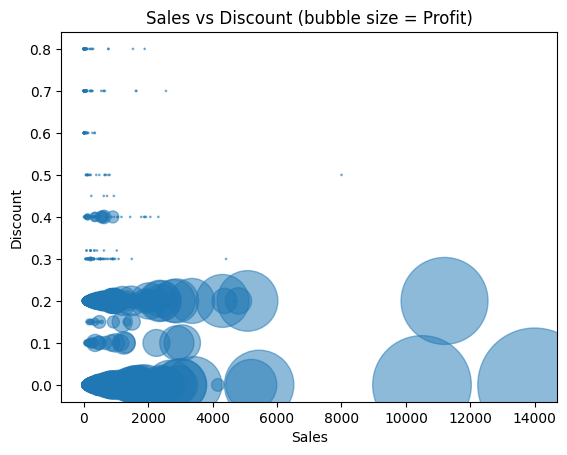

In [50]:
fig, ax = plt.subplots()
ax.scatter(
    ecom_data_numeric['Sales'],
    ecom_data_numeric['Discount'],
    s=ecom_data_numeric['Profit'].clip(lower=1),
    alpha=0.5
)
ax.set_xlabel('Sales')
ax.set_ylabel('Discount')
plt.title('Sales vs Discount (bubble size = Profit)')
plt.show()

Variance explained by PC1: 32.57%


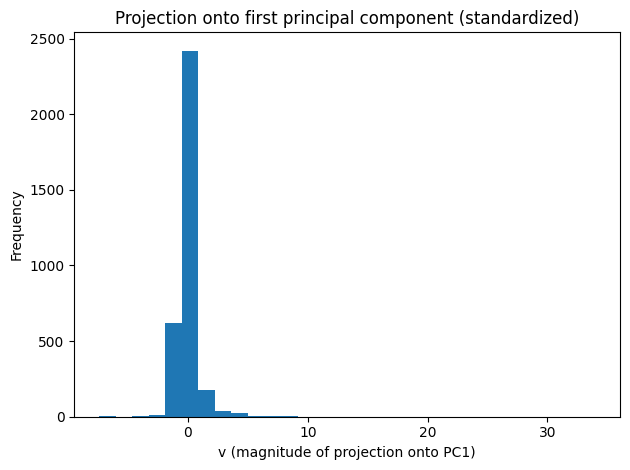

In [43]:
# standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
ecom_scaled = scaler.fit_transform(ecom_data_numeric)

# fit PCA
pca = decomposition.PCA(n_components=1)
pca.fit(ecom_scaled)

print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]:.2%}")

# project onto PC1
v = (ecom_scaled - ecom_scaled.mean(axis=0)).dot(pca.components_[0])

# histogram
plt.hist(v, bins=30)
plt.title("Projection onto first principal component (standardized)")
plt.xlabel("v (magnitude of projection onto PC1)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [44]:
print(pca.explained_variance_ratio_[0])

0.32569455240162654


Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?

Yes the histogram says exactly that. The projection v is the data represented using only PC1, computed the Week 8 way. Each observation gets collapsed down to a single number, its "score" along the direction of maximum variance.

How much of the variance would this capture?

PC1 captures about 40.7% of the variance which means if I represent the data using only its projection onto the first principal component, I am retaining less than half the information and throwing away the other ~59%





In [51]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import pandas as pd

results = []

for target in ecom_data_numeric.columns:
    features = [col for col in ecom_data_numeric.columns if col != target]
    
    X = ecom_data_numeric[features]
    y = ecom_data_numeric[target]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    
    r2 = r2_score(y_test, lr.predict(X_test))
    results.append({'target': target, 'r2': round(r2, 3)})

results_df = pd.DataFrame(results).sort_values('r2', ascending=False)
print(results_df)

        target     r2
4       Profit  0.230
1        Sales  0.183
0  Postal Code  0.001
3     Discount -0.013
2     Quantity -0.024


Which features seem most likely to be useful to predict other features?

The feature profit seems most likely to be useful to predict other features, as it has the highest R^2 value when used as a target variable in a linear regression model. This suggests that profit is strongly correlated with the other features in the dataset, and can be predicted with relatively high accuracy using the other features as predictors.


The data are somewhat what I'd expect from a retail dataset. Profit and Sales are at least somewhat related to each other and to the other variables, which makes sense. But the R² values are pretty low across the board (the best was 0.23 for Profit), which suggests the linear relationships aren't that strong. The data are probably usable but a linear model alone isn't going to be enough, something like a random forest would likely do better given the non-linear relationships.

There are definitely outliers. Looking at the PCA histogram, the vast majority of points are clustered tightly around 0, but there's a long right tail stretching out past 30 even after standardizing. That's a clear sign of a handful of extreme observations probably unusually large orders or high-profit transactions that are far from the typical customer. These are worth investigating before doing any serious modeling.

As for PCA, it doesn't really suggest a clean low-dimensional representation. PC1 only captured about 40.7% of the variance, which means I will be throwing away 60% of the information if I reduced to just one component. That's too much to be useful. I will probably need 3 or 4 components to get to 80%+ variance explained, which at that point I am not really simplifying the data that much. So no, PCA doesn't suggest an obvious way to reduce the dimensions here, the data just has too many independent sources of variation for that to work cleanly.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

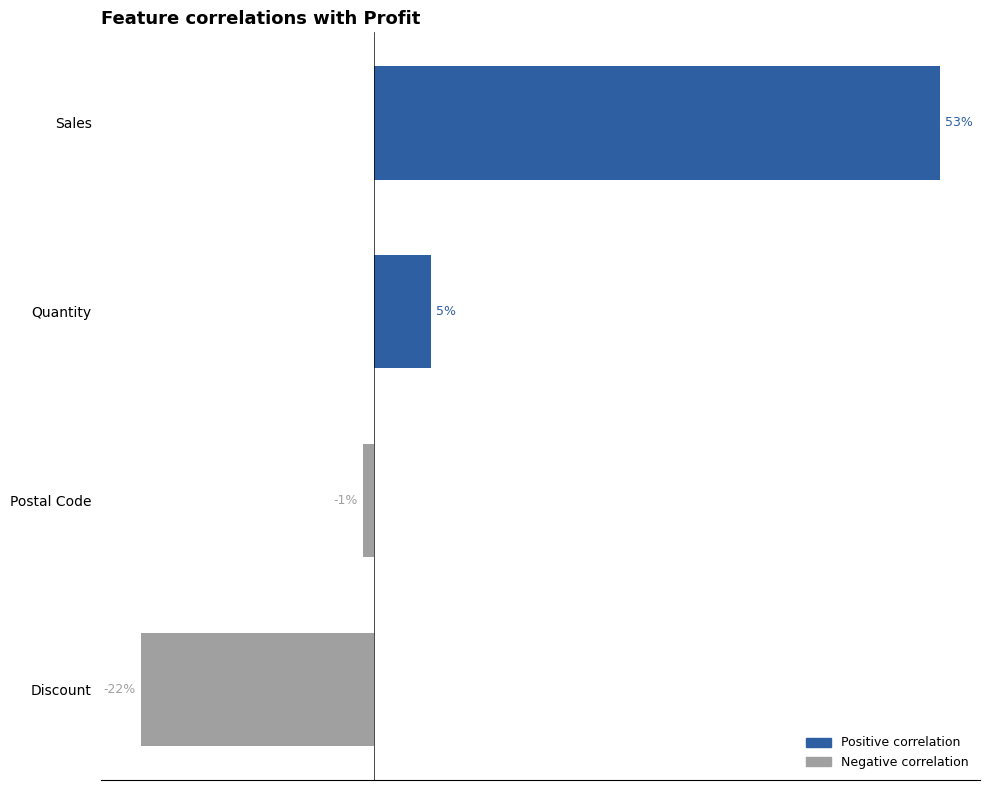

In [55]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

correlations = ecom_data_numeric.corr()['Profit'].drop('Profit').sort_values()

fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#2e5fa3' if v >= 0 else '#a0a0a0' for v in correlations.values]
bars = ax.barh(correlations.index, correlations.values, color=colors, height=0.6)

# add value labels
for bar, val in zip(bars, correlations.values):
    ax.text(val + 0.005 if val >= 0 else val - 0.005,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.0%}', va='center',
            ha='left' if val >= 0 else 'right',
            fontsize=9, color='#2e5fa3' if val >= 0 else '#a0a0a0')

ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Correlation with Profit', fontsize=10)
ax.set_title('Feature correlations with Profit', fontsize=13, fontweight='bold', loc='left')
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(left=False)
ax.xaxis.set_visible(False)

positive_patch = mpatches.Patch(color='#2e5fa3', label='Positive correlation')
negative_patch = mpatches.Patch(color='#a0a0a0', label='Negative correlation')
ax.legend(handles=[positive_patch, negative_patch], loc='lower right', fontsize=9, frameon=False)

plt.tight_layout()
plt.show()